In [1]:
## Riboflavin example to illustrate hypothesis generation

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

dpl = False  # set True to save plot PDFs to plotdir
plotdir = os.path.abspath(os.path.join("..", "Slides", "figures"))

# Load riboflavin data: 71 obs, 4088 gene-expression predictors + outcome y
data_path = os.path.join("..", "Data", "riboflavin.csv")
data = pd.read_csv(data_path)
print(f"data shape: {data.shape}")
print(f"first 5 columns: {list(data.columns[:5])}")


data shape: (71, 4089)
first 5 columns: ['y', 'AADK_at', 'AAPA_at', 'ABFA_at', 'ABH_at']


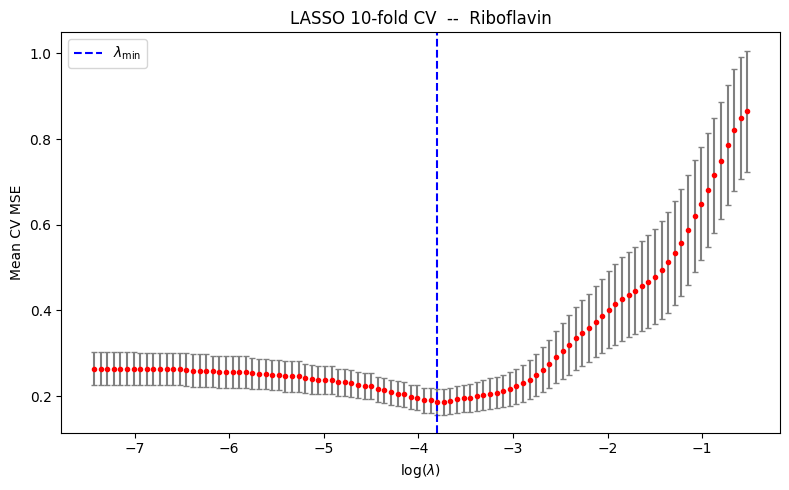

non-zero coefs at lambda.min: 52
non-zero coefs at lambda.1se: 37
lambda.min = 0.02234, lambda.1se = 0.04489


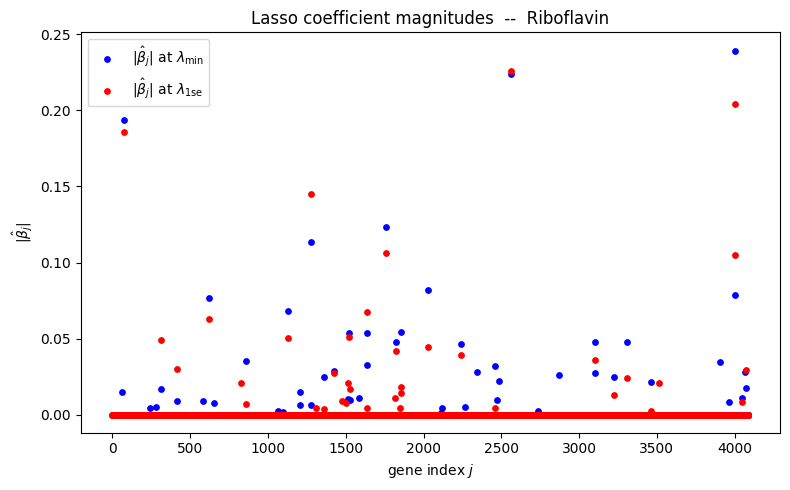

In [2]:
# Lasso with 10-fold CV (matches the R cv.glmnet call in the
# parallel R script). Standardize predictors so coefficient magnitudes
# are comparable across genes.

y = data["y"].to_numpy()
X = data.drop(columns=["y"]).to_numpy()

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

np.random.seed(6072015)
lasso_cv = LassoCV(cv=10, alphas=100, random_state=6072015,
                   max_iter=20000, n_jobs=1)
lasso_cv.fit(X_std, y)

# CV curve: mean MSE +/- 1 SE across alphas
mean_mse = lasso_cv.mse_path_.mean(axis=1)
sem_mse  = lasso_cv.mse_path_.std(axis=1) / np.sqrt(lasso_cv.mse_path_.shape[1])

plt.figure(figsize=(8, 5))
plt.errorbar(np.log(lasso_cv.alphas_), mean_mse, yerr=sem_mse,
             fmt="o", color="red", ecolor="grey", markersize=3, capsize=2)
plt.axvline(np.log(lasso_cv.alpha_), color="blue", linestyle="--",
            label=r"$\lambda_{\min}$")
plt.xlabel(r"$\log(\lambda)$")
plt.ylabel("Mean CV MSE")
plt.title("LASSO 10-fold CV  --  Riboflavin")
plt.legend()
plt.tight_layout()
if dpl:
    plt.savefig(os.path.join(plotdir, "RiboflavinCV.pdf"))
plt.show()

# lambda.1se: largest lambda whose CV error is within 1 SE of the min
min_idx    = int(np.argmin(mean_mse))
threshold  = mean_mse[min_idx] + sem_mse[min_idx]
lambda_1se = lasso_cv.alphas_[np.where(mean_mse <= threshold)[0][0]]

lasso_1se = Lasso(alpha=lambda_1se, max_iter=20000)
lasso_1se.fit(X_std, y)
coef_1se = np.abs(lasso_1se.coef_)
coef_min = np.abs(lasso_cv.coef_)

print(f"non-zero coefs at lambda.min: {int((coef_min > 0).sum())}")
print(f"non-zero coefs at lambda.1se: {int((coef_1se > 0).sum())}")
print(f"lambda.min = {lasso_cv.alpha_:.5f}, lambda.1se = {lambda_1se:.5f}")

# Coefficient magnitudes at the two lambdas
plt.figure(figsize=(8, 5))
plt.scatter(np.arange(len(coef_min)), coef_min, c="blue", s=15,
            label=r"$|\hat\beta_j|$ at $\lambda_{\min}$")
plt.scatter(np.arange(len(coef_1se)), coef_1se, c="red", s=15,
            label=r"$|\hat\beta_j|$ at $\lambda_{1\mathrm{se}}$")
plt.xlabel("gene index $j$")
plt.ylabel(r"$|\hat\beta_j|$")
plt.title("Lasso coefficient magnitudes  --  Riboflavin")
plt.legend()
plt.tight_layout()
if dpl:
    plt.savefig(os.path.join(plotdir, "RiboflavinCoef.pdf"))
plt.show()
